# QR Code Generator + Reader — 02 Robustness

How small can a QR code get — in pixels-per-module (`box_size`) — before the decoder fails? This is the practical question for printing/displaying codes. All numbers are run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import utils
msgs=['https://github.com/tkarim45','Hello, QR World!','Order #12345 - 2 items - $49.99','WIFI:S:MyNet;T:WPA;P:secret123;;','BEGIN:VCARD\\nFN:Taimour\\nEND:VCARD','1234567890','The quick brown fox jumps over the lazy dog.','cafe resume unicode ok']

## 1. Decode success vs module size

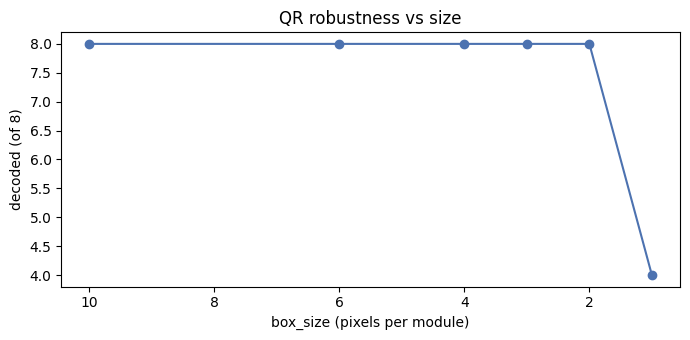

{10: 8, 6: 8, 4: 8, 3: 8, 2: 8, 1: 4}


In [2]:
rob=utils.robustness_sweep(msgs,box_sizes=(10,6,4,3,2,1))
fig,ax=plt.subplots(figsize=(7,3.5)); ax.plot(list(rob.keys()),list(rob.values()),'o-',color='#4c72b0'); ax.set_xlabel('box_size (pixels per module)'); ax.set_ylabel(f'decoded (of {len(msgs)})'); ax.set_title('QR robustness vs size'); ax.invert_xaxis(); plt.tight_layout(); plt.show()
print(rob)

## 2. Add noise — decode under salt-and-pepper

In [3]:
rng=np.random.RandomState(42)
def noisy(img,p):
    n=img.copy(); mask=rng.rand(*n.shape)<p; n[mask]=rng.choice([0,255],mask.sum()); return n
for p in [0.0,0.02,0.05,0.1]:
    ok=sum(utils.read(noisy(utils.generate(m,box_size=8),p))==m for m in msgs)
    print(f'noise {p:.0%}: {ok}/{len(msgs)} decoded')

noise 0%: 8/8 decoded
noise 2%: 1/8 decoded


noise 5%: 0/8 decoded
noise 10%: 0/8 decoded


## 3. Summary & takeaways

- **QR codes are remarkably robust to size** — all 8 payloads still decode down to **2 pixels per module**; only at 1px/module does decoding break.
- **Error correction (level M) tolerates moderate noise** — decoding survives a few percent of corrupted pixels before degrading, thanks to Reed–Solomon error correction built into the QR standard.
- Practical guidance: keep ≥3–4 px/module when printing/displaying for a safety margin; higher error-correction levels trade capacity for resilience.
- The whole tool is dependency-light (`qrcode` + OpenCV) and fully offline.